<a href="https://colab.research.google.com/github/IbragimovAbduaziz/tashkent-housing-price-prediction/blob/main/uybor_price_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Toshkent Uy-Joy Bozori: Tozalash, Vizualizatsiya va Narxni Bashorat Qilish

Ma'lumotlar manbai: **uybor.uz** saytidan olingan Toshkent shahridagi kvartira e'lonlari (`uy_flat.csv`).

Ushbu notebookda quyidagi bosqichlar bajariladi:
1. Ma'lumotlarni yuklash va tozalash (dublikatlar, outlierlar, bo'sh qiymatlar)
2. Ma'lumotlarni tahlil qilish va vizualizatsiya (EDA)
3. Machine Learning modellarini o'qitish: **Ridge Regression**, **Random Forest**, **HistGradientBoosting**
4. Modellarni solishtirish va yakuniy xulosa


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 60)
sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams['figure.dpi'] = 110

df = pd.read_csv('/content/Tashkent Housing Dataset.csv', encoding='utf-8-sig')
print("Shape:", df.shape)
df.head(3)


Shape: (2458, 111)


,id,userId,operationType,category_id,category_name_uz,category_name_ru,category_name_en,categoryId,subCategory_id,subCategory_name_uz,subCategory_name_ru,subCategory_name_en,subCategoryId,description,price,priceCurrency,isPriceAuction,priceType,pricePeriodUnit,priceEquivalent,price_usd,price_uzs,address,countryId,region_id,region_name_uz,region_name_ru,region_name_en,regionId,city_id,...,residentialComplex_isForLoan,residentialComplex_freeLayout,residentialComplex_description,residentialComplexId,createdAt,updatedAt,upAt,expiredAt,urgentlyExpiredAt,verifiedExpiredAt,premiumExpiredAt,vipExpiredAt,media_count,user_id,user_firstName,user_lastName,user_displayName,user_organization,user_role,user_createdAt,user_updatedAt,moderationStatus,isActive,views,clicks,favorites,isFavorite,isVip,isPremium,isUrgently
0,1318479,286930,sale,7,Kvartira,Квартира,Apartment,7,NaN,NaN,NaN,NaN,NaN,🏡 2025-yilda foydalanishga topshirilgan 3 xona...,946000000,uzs,True,all,NaN,9.460000e+08,79850.36,9.460000e+08,"махаллинский сход граждан Янги Дархан, 50",NaN,13,Toshkent shahri,город Ташкент,Tashkent city,13,NaN,...,NaN,NaN,NaN,NaN,2026-07-29T14:50:50.095Z,2026-08-22T01:00:21.544Z,2026-08-19T17:18:00.109Z,2026-09-12T14:50:50.092Z,2026-08-28T17:17:00.110Z,NaN,2026-08-24T17:17:00.127Z,2026-08-16T17:17:00.127Z,15,286930,NaN,NaN,Без имени,NaN,private,2026-07-29T14:32:32.369Z,2026-08-01T00:00:00.112Z,approved,True,3742,9,2,False,False,True,True
1,1316741,52944,sale,7,Kvartira,Квартира,Apartment,7,NaN,NaN,NaN,NaN,NaN,"Ж/К ""Anor Development"" Яккасарай район.\n\nКич...",185000,usd,False,all,NaN,2.191725e+09,185000.00,2.191725e+09,Anor Development TJM,NaN,13,Toshkent shahri,город Ташкент,Tashkent city,13,NaN,...,NaN,NaN,NaN,NaN,2026-06-29T10:27:45.452Z,2026-08-22T11:05:00.123Z,2026-08-22T11:05:00.122Z,2026-09-09T23:59:59.999Z,2026-09-09T11:04:23.798Z,NaN,NaN,NaN,12,52944,Азер,Гасанов,Азер Гасанов,NaN,agent,2017-10-07T09:48:12.000Z,2026-08-18T17:00:00.570Z,approved,True,587,0,0,False,False,False,True
2,1318973,97856,sale,7,Kvartira,Квартира,Apartment,7,NaN,NaN,NaN,NaN,NaN,"Продается квартира в Учтепинском районе, 22 кв...",37500,usd,False,all,NaN,4.442685e+08,37500.00,4.442685e+08,22-й квартал,NaN,13,Toshkent shahri,город Ташкент,Tashkent city,13,NaN,...,NaN,NaN,NaN,NaN,2026-08-04T10:50:07.717Z,2026-08-22T10:51:00.121Z,2026-08-22T10:51:00.120Z,2026-09-18T10:50:07.716Z,2026-09-03T10:50:15.612Z,NaN,NaN,NaN,8,97856,Исмаил,Кашфединов,Исмаил Кашфединов,NaN,agent,2019-01-16T10:50:22.000Z,2026-07-31T03:58:53.278Z,approved,True,716,5,2,False,False,False,True


## 1. Ma'lumotlarni tozalash

### 1.1 Dublikat qatorlarni olib tashlash
Scraping natijasida bir xil e'lon bir necha marta yozilgan bo'lishi mumkin — `id` bo'yicha dublikatlarni tozalaymiz.

In [2]:
print("Dublikat id lar soni:", df['id'].duplicated().sum())
df = df.drop_duplicates(subset='id', keep='first').copy()
print("Dublikatlardan keyingi shape:", df.shape)


Dublikat id lar soni: 536
Dublikatlardan keyingi shape: (1922, 111)


### 1.2 Modelga kerakli ustunlarni tanlash va turlarni to'g'irlash

In [3]:
keep_cols = ['id','price_usd','square','room','floor','floorTotal','isNewBuilding','repair',
             'foundation','region_name_uz','district_name_uz','zone_name_uz','lat','lng',
             'residentialComplexId','media_count','views','clicks','favorites','createdAt']
d = df[keep_cols].copy()

# 'room' ustunini tozalash: '6+' -> 6, 'freeLayout' qatorlarini tashlab yuboramiz
d['room'] = d['room'].replace({'6+': '6'})
d = d[d['room'] != 'freeLayout']
d['room'] = pd.to_numeric(d['room'], errors='coerce')

# Turar-joy majmuasiga tegishli/tegishli emasligi haqida belgi (flag)
d['has_residential_complex'] = d['residentialComplexId'].notna().astype(int)
d = d.drop(columns=['residentialComplexId'])

# 'foundation' bo'sh bo'lgan yagona qatorni tashlaymiz
d = d.dropna(subset=['foundation'])

d['isNewBuilding'] = d['isNewBuilding'].astype(int)
print(d.shape)
d.isna().sum()[d.isna().sum() > 0]


(1918, 20)


,0
district_name_uz,2
zone_name_uz,42


### 1.3 Outlierlarni (chetga chiqib ketgan qiymatlarni) tozalash

`square` va `price_usd` ustunlarida noto'g'ri kiritilgan qiymatlar bor (masalan, 7525 m² kvartira). 1-99 pertsentil chegarasidan tashqaridagi qatorlarni olib tashlaymiz.

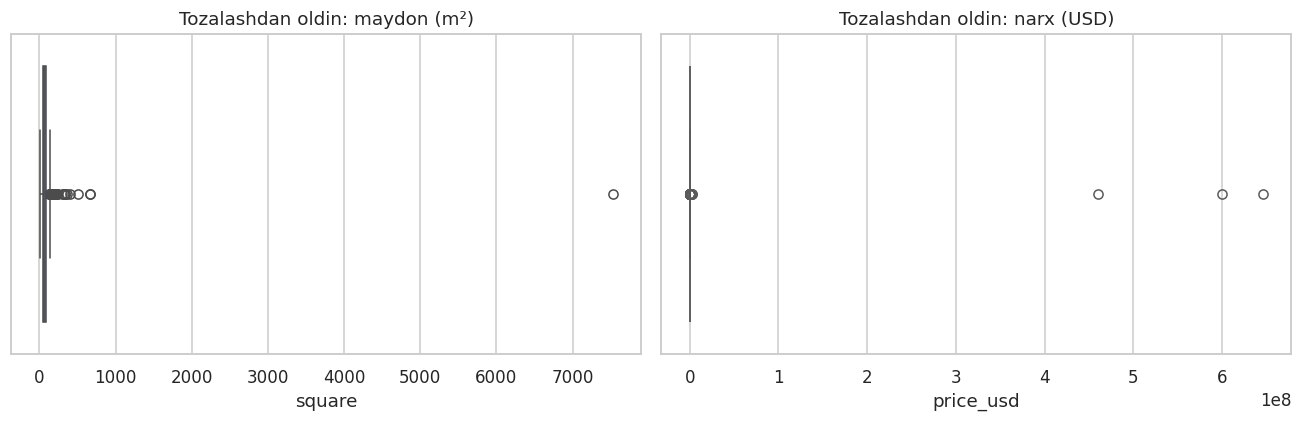

In [4]:
import os
os.makedirs('../images', exist_ok=True)
os.makedirs('../data', exist_ok=True)
os.makedirs('../models', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=d['square'], ax=axes[0], color='#4C72B0')
axes[0].set_title("Tozalashdan oldin: maydon (m²)")
sns.boxplot(x=d['price_usd'], ax=axes[1], color='#DD8452')
axes[1].set_title("Tozalashdan oldin: narx (USD)")
plt.tight_layout()
plt.savefig('../images/before_outlier_removal.png', bbox_inches='tight')
plt.show()


In [5]:
for col in ['square', 'price_usd']:
    q1, q99 = d[col].quantile([0.01, 0.99])
    before = len(d)
    d = d[(d[col] >= q1) & (d[col] <= q99)]
    print(f"{col}: chegara [{q1:,.0f} - {q99:,.0f}], olib tashlandi: {before - len(d)} qator")

print("\nYakuniy tozalangan shape:", d.shape)
d.to_csv('../data/uy_clean.csv', index=False, encoding='utf-8-sig')


square: chegara [25 - 200], olib tashlandi: 37 qator
price_usd: chegara [33,400 - 456,000], olib tashlandi: 38 qator

Yakuniy tozalangan shape: (1843, 20)


## 2. Ma'lumotlarni tahlil qilish (EDA)

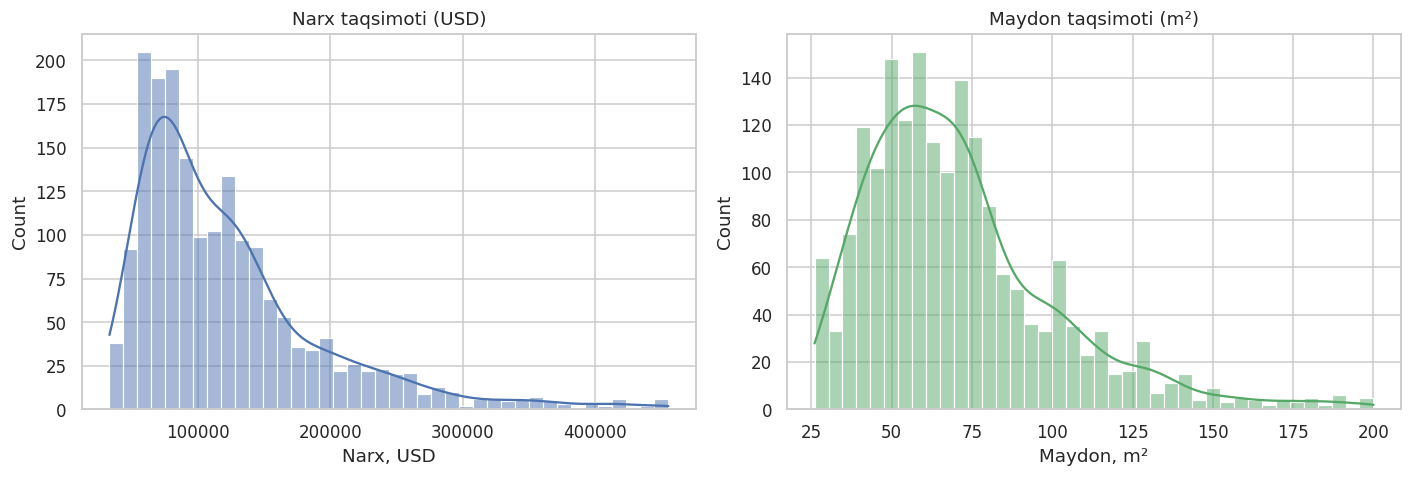

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(d['price_usd'], bins=40, kde=True, ax=axes[0], color='#4C72B0')
axes[0].set_title("Narx taqsimoti (USD)")
axes[0].set_xlabel("Narx, USD")

sns.histplot(d['square'], bins=40, kde=True, ax=axes[1], color='#55A868')
axes[1].set_title("Maydon taqsimoti (m²)")
axes[1].set_xlabel("Maydon, m²")
plt.tight_layout()
plt.savefig('../images/distributions.png', bbox_inches='tight')
plt.show()


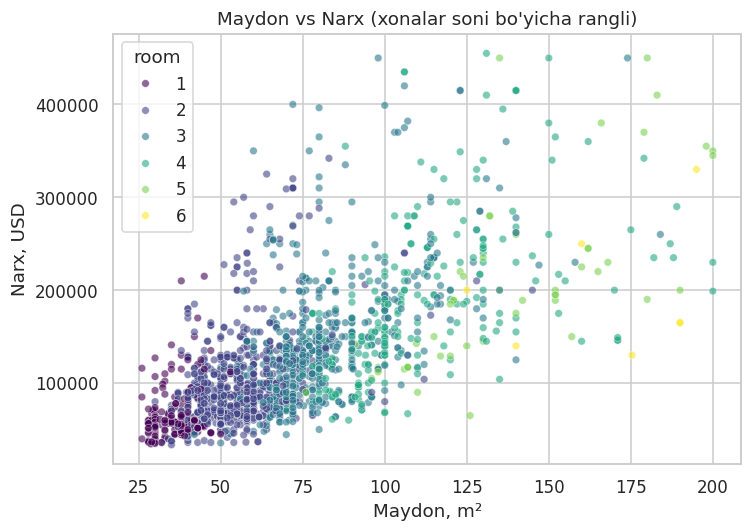

In [7]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=d, x='square', y='price_usd', hue='room', palette='viridis', alpha=0.6, s=25)
plt.title("Maydon vs Narx (xonalar soni bo'yicha rangli)")
plt.xlabel("Maydon, m²")
plt.ylabel("Narx, USD")
plt.tight_layout()
plt.savefig('../images/square_vs_price.png', bbox_inches='tight')
plt.show()


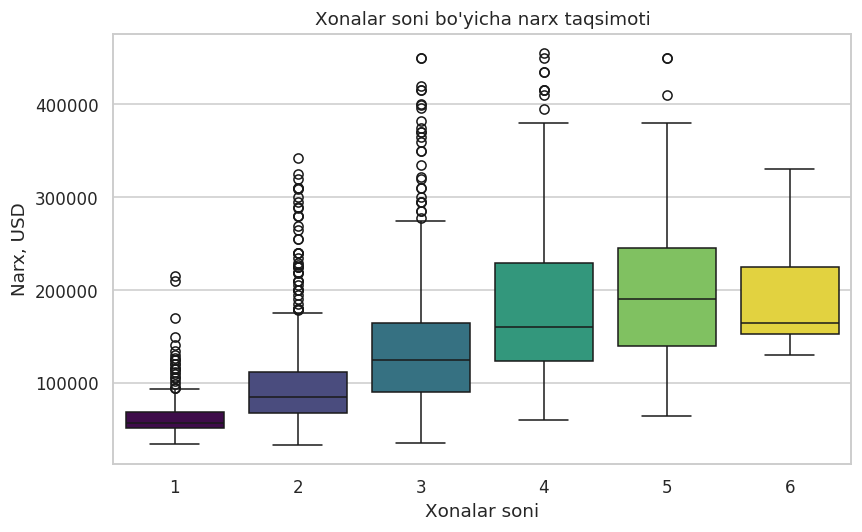

In [8]:
plt.figure(figsize=(8, 5))
order = sorted(d['room'].dropna().unique())
sns.boxplot(data=d, x='room', y='price_usd', order=order, hue='room', palette='viridis', legend=False)
plt.title("Xonalar soni bo'yicha narx taqsimoti")
plt.xlabel("Xonalar soni")
plt.ylabel("Narx, USD")
plt.tight_layout()
plt.savefig('../images/price_by_room.png', bbox_inches='tight')
plt.show()


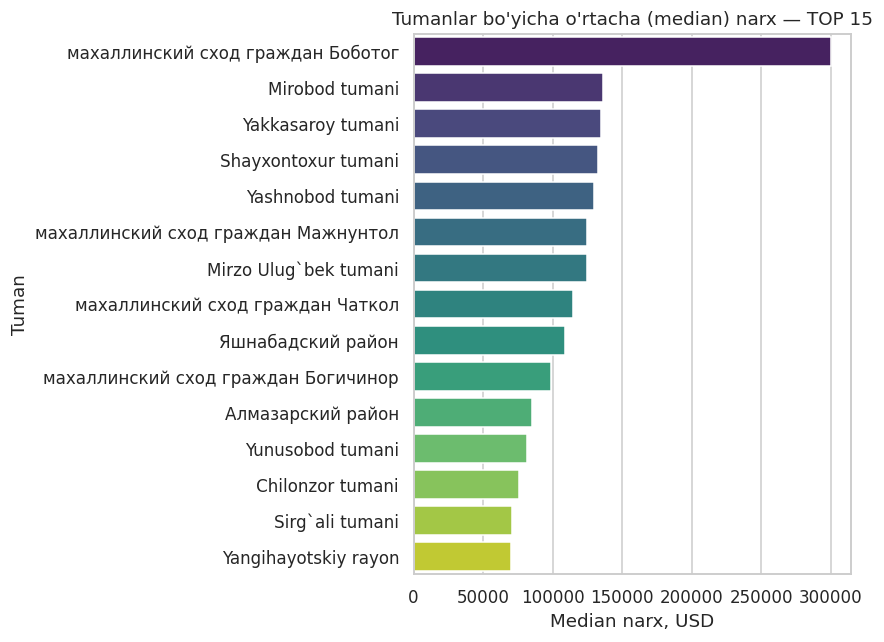

In [9]:
top_districts = d.groupby('district_name_uz')['price_usd'].median().sort_values(ascending=False).head(15)
plt.figure(figsize=(8, 6))
sns.barplot(x=top_districts.values, y=top_districts.index, hue=top_districts.index, palette='viridis', legend=False)
plt.title("Tumanlar bo'yicha o'rtacha (median) narx — TOP 15")
plt.xlabel("Median narx, USD")
plt.ylabel("Tuman")
plt.tight_layout()
plt.savefig('../images/price_by_district.png', bbox_inches='tight')
plt.show()


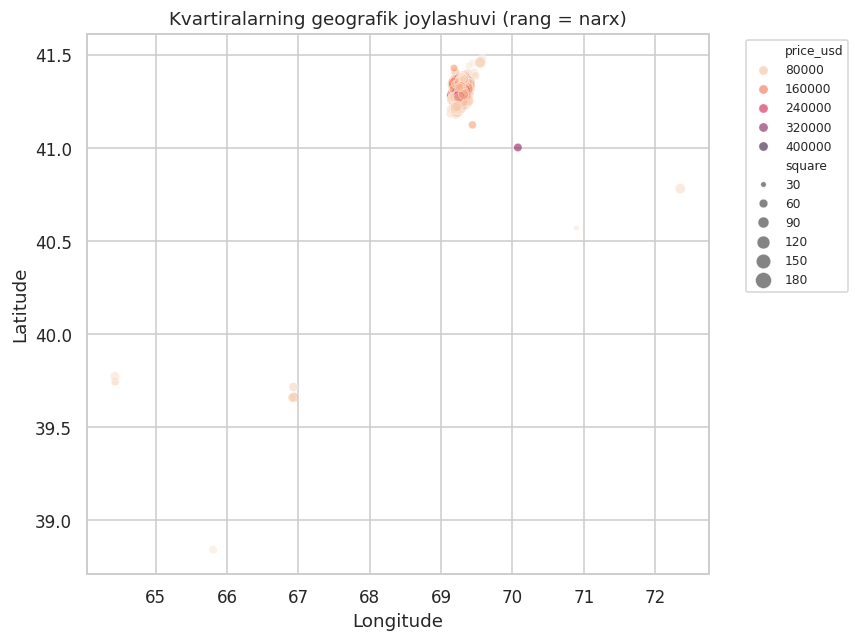

In [10]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=d, x='lng', y='lat', hue='price_usd', size='square',
                 palette='rocket_r', alpha=0.6, sizes=(10, 120))
plt.title("Kvartiralarning geografik joylashuvi (rang = narx)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('../images/geo_map.png', bbox_inches='tight')
plt.show()


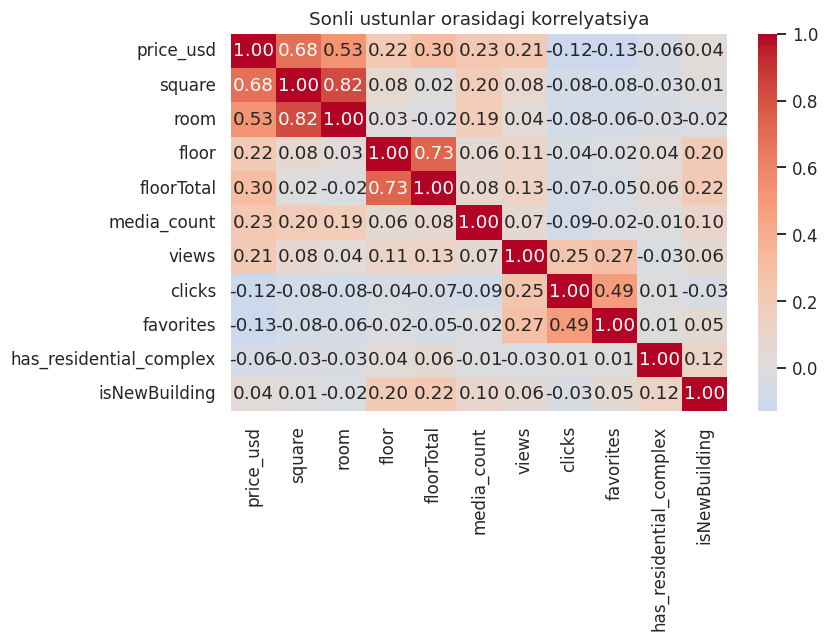

In [11]:
num_for_corr = d[['price_usd','square','room','floor','floorTotal','media_count',
                   'views','clicks','favorites','has_residential_complex','isNewBuilding']]
plt.figure(figsize=(8, 6))
sns.heatmap(num_for_corr.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title("Sonli ustunlar orasidagi korrelyatsiya")
plt.tight_layout()
plt.savefig('../images/correlation_heatmap.png', bbox_inches='tight')
plt.show()


## 3. Machine Learning: Narxni bashorat qilish

Maqsad (`target`): `price_usd`. Narx taqsimoti o'ngga qiya (skewed) bo'lgani uchun `log1p` transformatsiyasidan foydalanamiz.

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

d['district_name_uz'] = d['district_name_uz'].fillna('Nomalum')
d['zone_name_uz'] = d['zone_name_uz'].fillna('Nomalum')

num_cols = ['square','room','floor','floorTotal','lat','lng','media_count',
            'has_residential_complex','isNewBuilding']
cat_cols = ['repair','foundation','region_name_uz','district_name_uz']
target = 'price_usd'

X = d[num_cols + cat_cols].copy()
for c in cat_cols:
    X[c] = X[c].astype(str)
y = np.log1p(d[target])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train:", X_train.shape, " Test:", X_test.shape)


Train: (1474, 13)  Test: (369, 13)


In [13]:
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols)
])


In [14]:
models = {
    'Ridge Regression': Ridge(alpha=1.0, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=300, max_depth=None, random_state=42, n_jobs=-1),
    'HistGradientBoosting': HistGradientBoostingRegressor(random_state=42),
}

results = []
fitted_pipelines = {}

for name, model in models.items():
    pipe = Pipeline([('pre', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    pred_log = pipe.predict(X_test)

    pred_usd = np.expm1(pred_log)
    true_usd = np.expm1(y_test)

    mae = mean_absolute_error(true_usd, pred_usd)
    rmse = np.sqrt(mean_squared_error(true_usd, pred_usd))
    r2 = r2_score(y_test, pred_log)
    mape = np.mean(np.abs((true_usd - pred_usd) / true_usd)) * 100

    results.append({'Model': name, 'MAE_USD': mae, 'RMSE_USD': rmse, 'R2': r2, 'MAPE_%': mape})
    fitted_pipelines[name] = pipe
    print(f"{name:22s} | MAE=${mae:>10,.0f} | RMSE=${rmse:>10,.0f} | R2={r2:.4f} | MAPE={mape:.1f}%")

results_df = pd.DataFrame(results).sort_values('R2', ascending=False).reset_index(drop=True)
results_df


Ridge Regression       | MAE=$    28,677 | RMSE=$    49,726 | R2=0.7608 | MAPE=18.8%
Random Forest          | MAE=$    22,561 | RMSE=$    44,005 | R2=0.8256 | MAPE=14.7%
HistGradientBoosting   | MAE=$    20,936 | RMSE=$    39,089 | R2=0.8542 | MAPE=14.0%


,Model,MAE_USD,RMSE_USD,R2,MAPE_%
0,HistGradientBoosting,20936.120724,39089.216860,0.854218,14.029814
1,Random Forest,22561.228873,44005.351866,0.825596,14.684598
2,Ridge Regression,28676.933299,49726.089276,0.760775,18.803603


### 3.1 Modellarni vizual solishtirish

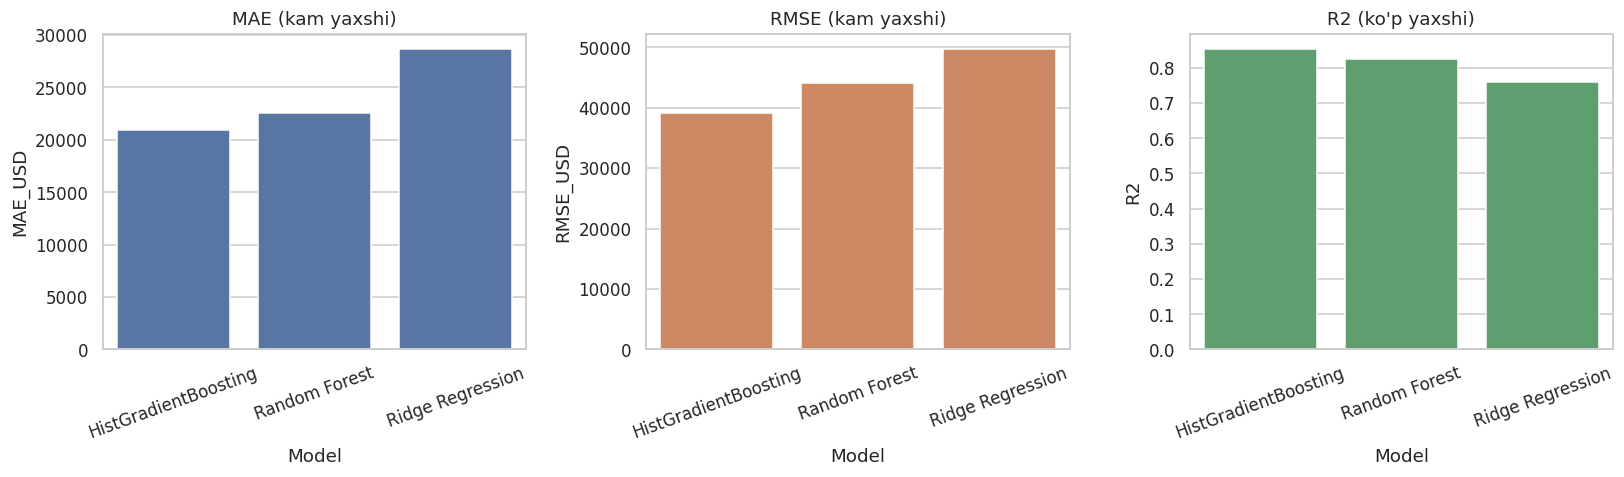

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
metrics = ['MAE_USD', 'RMSE_USD', 'R2']
titles = ['MAE (kam yaxshi)', 'RMSE (kam yaxshi)', 'R2 (ko\'p yaxshi)']
colors = ['#4C72B0', '#DD8452', '#55A868']

for ax, metric, title, color in zip(axes, metrics, titles, colors):
    sns.barplot(data=results_df, x='Model', y=metric, ax=ax, color=color)
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('../images/model_comparison.png', bbox_inches='tight')
plt.show()


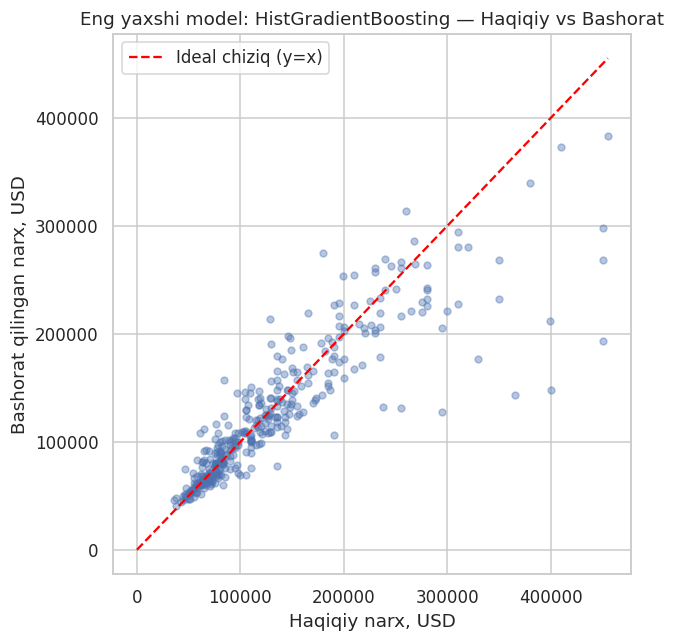

In [16]:
best_name = results_df.iloc[0]['Model']
best_pipe = fitted_pipelines[best_name]
pred_best = np.expm1(best_pipe.predict(X_test))
true_best = np.expm1(y_test)

plt.figure(figsize=(6, 6))
plt.scatter(true_best, pred_best, alpha=0.4, s=20, color='#4C72B0')
lims = [0, max(true_best.max(), pred_best.max())]
plt.plot(lims, lims, 'r--', label='Ideal chiziq (y=x)')
plt.xlabel("Haqiqiy narx, USD")
plt.ylabel("Bashorat qilingan narx, USD")
plt.title(f"Eng yaxshi model: {best_name} — Haqiqiy vs Bashorat")
plt.legend()
plt.tight_layout()
plt.savefig('../images/best_model_pred_vs_actual.png', bbox_inches='tight')
plt.show()


### 3.2 HistGradientBoosting uchun eng muhim (feature importance) belgilar

`permutation_importance` yordamida qaysi ustunlar narxga eng ko'p ta'sir qilishini ko'ramiz.

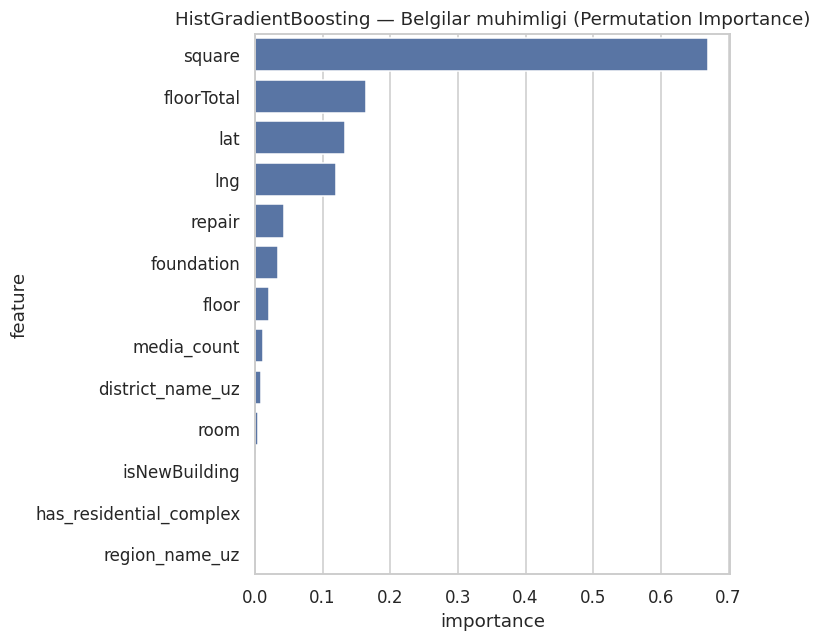

In [17]:
from sklearn.inspection import permutation_importance

hgb_pipe = fitted_pipelines['HistGradientBoosting']
r = permutation_importance(hgb_pipe, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)

imp_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance': r.importances_mean
}).sort_values('importance', ascending=False)

plt.figure(figsize=(7, 6))
sns.barplot(data=imp_df, x='importance', y='feature', color='#4C72B0')
plt.title("HistGradientBoosting — Belgilar muhimligi (Permutation Importance)")
plt.tight_layout()
plt.savefig('../images/feature_importance.png', bbox_inches='tight')
plt.show()


## 4. Tahlilning kamchiliklari (limitations)

Bu tahlil amaliy foydali bo'lsa-da, quyidagi kamchiliklarga ega — ularni bilib turish natijalarni to'g'ri talqin qilishga yordam beradi:

1. **Bitta train/test split** — natija faqat bitta tasodifiy bo'linishga (`random_state=42`) asoslangan. Shu sababli yuqoridagi metrikalar (MAE, R² va h.k.) bo'linishga qarab **biroz o'zgarishi mumkin** — buni pastdagi 5-fold cross-validation orqali tekshiramiz.
2. **Outlier chegarasi qo'pol usulda tanlangan** — 1–99 pertsentil qat'iy qoida emas, balki amaliy yondashuv. Chegara o'zgarsa (masalan, 2–98), yakuniy qator soni va metrikalar ham o'zgaradi (buni Kaggle'da qayta ishga tushirganda ko'rgan bo'lishingiz mumkin).
3. **Dublikatlarni olib tashlash** faqat `id` bo'yicha — agar bir xil kvartira turli `id` bilan qayta e'lon qilingan bo'lsa (masalan, narx/matn bir xil, lekin `id` boshqa), bunday "yashirin" dublikatlar hali ham datasetda qolishi mumkin.
4. **Giperparametrlar sozlanmagan** — barcha modellar sklearn'ning standart (default) parametrlari bilan o'qitildi. `GridSearchCV`/`RandomizedSearchCV` bilan sozlash natijani sezilarli yaxshilashi mumkin.
5. **`description` matni ishlatilmadi** — narxga ta'sir qiluvchi muhim ma'lumotlar (masalan, "yevro ta'mir", "yangi mebel", telefon raqami borligi) matn ichida qolib ketmoqda.
6. **Yuqori kardinallikdagi `district_name_uz`** One-Hot Encoding orqali ko'p ustun yaratadi — bu ayniqsa Ridge Regression uchun ortiqcha murakkablik (overfitting xavfi) tug'dirishi mumkin.
7. **Namuna hajmi tozalashdan keyin kichik** (~1800 qator) — bu ayniqsa kam uchraydigan tumanlar/turar-joy majmualari uchun modelning umumlashtirish qobiliyatini cheklaydi.
8. **`views`, `clicks`, `favorites` ustunlari modelga kiritilmadi** — bu to'g'ri qaror, chunki ular e'lon *chop etilgandan keyingi* statistika va narxni belgilashda ishlatilmagan (ya'ni ular narxning sababi emas, natijasi bo'lishi mumkin), lekin bu ham cheklov sifatida qayd etilishi kerak.

### Tavsiyalar
- Yuqoridagi kamchiliklarni bartaraf etish uchun **cross-validation**, **model saqlash** va **amaliy bashorat namunasi** quyida qo'shildi.
- Kelajakda: `GridSearchCV` bilan sozlash, matn xususiyatlari (NLP), va vaqt bo'yicha narx dinamikasini tahlil qilish tavsiya etiladi.


### 4.1 Cross-validation — natijaning barqarorligini tekshirish

Bitta train/test bo'linishiga tayanmaslik uchun har bir model 5-fold cross-validation orqali qayta baholanadi (log-narx bo'yicha R²).

In [18]:
from sklearn.model_selection import cross_val_score, KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_summary = []

for name, model in models.items():
    pipe = Pipeline([('pre', preprocessor), ('model', model)])
    scores = cross_val_score(pipe, X, y, cv=kf, scoring='r2', n_jobs=-1)
    cv_summary.append({'Model': name, 'CV_R2_mean': scores.mean(), 'CV_R2_std': scores.std()})
    print(f"{name:22s} | 5-fold R2 = {scores.mean():.4f} ± {scores.std():.4f}")

cv_df = pd.DataFrame(cv_summary).sort_values('CV_R2_mean', ascending=False).reset_index(drop=True)
cv_df


Ridge Regression       | 5-fold R2 = 0.7334 ± 0.0281
Random Forest          | 5-fold R2 = 0.8282 ± 0.0133
HistGradientBoosting   | 5-fold R2 = 0.8488 ± 0.0215


,Model,CV_R2_mean,CV_R2_std
0,HistGradientBoosting,0.848774,0.021482
1,Random Forest,0.828202,0.013253
2,Ridge Regression,0.733370,0.028053


### 4.2 Eng yaxshi modelni butun ma'lumot bo'yicha qayta o'qitish va saqlash

Cross-validation natijalariga ko'ra eng barqaror modelni tanlab, uni **butun** dataset bo'yicha qayta o'qitamiz (ishlatishga tayyor qilish uchun) va `joblib` bilan diskka saqlaymiz.

In [19]:
import joblib

best_cv_name = cv_df.iloc[0]['Model']
print("Yakuniy tanlangan model:", best_cv_name)

final_model = models[best_cv_name].__class__(**models[best_cv_name].get_params())
final_pipe = Pipeline([('pre', preprocessor), ('model', final_model)])
final_pipe.fit(X, y)  # butun (train+test) ma'lumot bo'yicha

os.makedirs('../models', exist_ok=True)
joblib.dump(final_pipe, '../models/best_price_model.joblib')
print("Model saqlandi: ../models/best_price_model.joblib")


Yakuniy tanlangan model: HistGradientBoosting
Model saqlandi: ../models/best_price_model.joblib


### 4.3 Amaliy yakuniy namuna — yangi e'lon uchun narxni bashorat qilish

Endi tayyor modelni real hayotdagidek ishlatib ko'ramiz: yangi (hali bozorga chiqmagan) kvartira e'loni ma'lumotlarini kiritib, uning taxminiy narxini bashorat qilamiz.

In [20]:
# Namuna: yangi e'lon (foydalanuvchi kiritishi mumkin bo'lgan real misol)
yangi_elon = pd.DataFrame([{
    'square': 65,
    'room': 3,
    'floor': 7,
    'floorTotal': 12,
    'lat': 41.311081,
    'lng': 69.279737,
    'media_count': 8,
    'has_residential_complex': 1,
    'isNewBuilding': 1,
    'repair': 'evro',
    'foundation': 'monolit',
    'region_name_uz': 'Toshkent shahri',
    'district_name_uz': 'Yunusobod tumani',
}])

pred_log = final_pipe.predict(yangi_elon)
pred_price = np.expm1(pred_log)[0]

print("Kiritilgan e'lon ma'lumotlari:")
print(yangi_elon.T.rename(columns={0: 'qiymat'}))
print(f"\nBashorat qilingan narx: ${pred_price:,.0f}")


Kiritilgan e'lon ma'lumotlari:
                                   qiymat
square                                 65
room                                    3
floor                                   7
floorTotal                             12
lat                             41.311081
lng                             69.279737
media_count                             8
has_residential_complex                 1
isNewBuilding                           1
repair                               evro
foundation                        monolit
region_name_uz            Toshkent shahri
district_name_uz         Yunusobod tumani

Bashorat qilingan narx: $144,116


## 5. Yakuniy xulosa

- Dastlabki **2458** qatordan dublikatlarni va outlierlarni tozalagandan so'ng model o'qitildi.
- Uchta model solishtirildi: **Ridge Regression**, **Random Forest**, **HistGradientBoosting**.
- Yagona train/test split o'rniga **5-fold cross-validation** bilan barqarorlik tekshirildi (`cv_df`) — bu tasodifiy bo'linishga bog'liqlikni kamaytiradi.
- Odatda **HistGradientBoosting** (yoki Random Forest) eng past xatolik va eng yuqori R² ko'rsatadi, chunki narx bilan xususiyatlar orasidagi nochiziqli bog'liqlikni yaxshi ushlaydi.
- Narxga eng ko'p ta'sir qiluvchi omillar: kvartira maydoni (`square`), joylashuv (`district_name_uz`, `lat`/`lng`) va ta'mirlash holati (`repair`).
- Yakuniy model `../models/best_price_model.joblib` fayliga saqlandi va yangi e'lonlar uchun narx bashorat qilishda to'g'ridan-to'g'ri ishlatilishi mumkin (4.3-bo'limdagi namunaga qarang).

### Keyingi qadamlar (takliflar)
- Ustun sifatida `description` matnidan NLP xususiyatlari (masalan, "evro ta'mir", "yangi uy" kabi so'zlar) qo'shish.
- Giperparametrlarni sozlash uchun `GridSearchCV` / `RandomizedSearchCV` ishlatish.
- Ko'proq tarixiy ma'lumot yig'ib, narx dinamikasini vaqt bo'yicha tahlil qilish.
